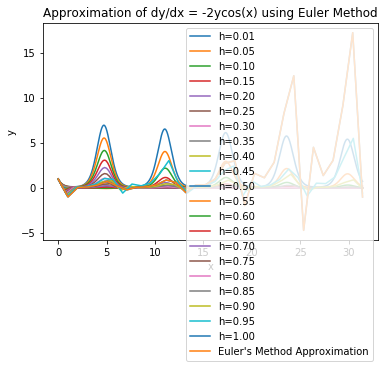

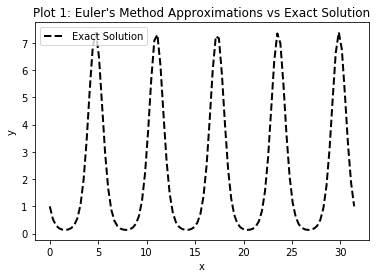

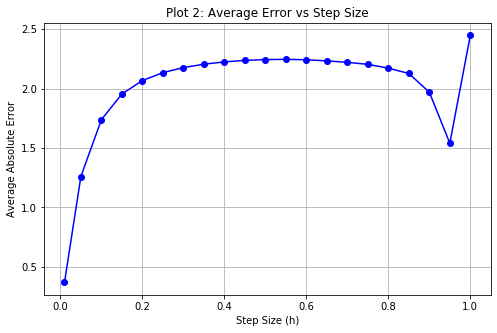

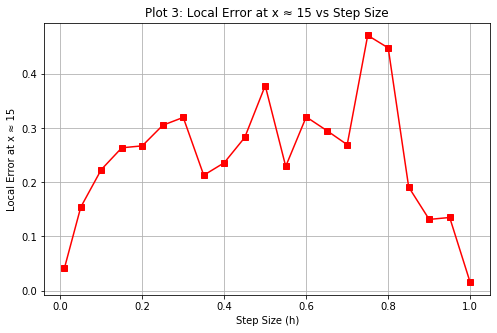

In [29]:
import numpy as np
import matplotlib.pyplot as plt



# Define parameters
stepSizes = [0.01] + list(np.arange(0.05, 1.05, 0.05))
realY = lambda x : np.exp(-2 * np.sin(x))
avgErrorList = []
localError15 = []
hPlot = []

# Function representing dy/dx = 2ycos(x)
def f(x, y):
    return -2*y*np.cos(x)


for h in stepSizes:
    x_start, x_end = 0, 10*np.pi
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1 # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # y-value average and error
    yValueAvg = np.average(y_values)
    trueY = realY(x_values)
    avgError = np.mean(np.abs(y_values - trueY))
    avgErrorList.append(avgError)
    
    # 2. Local error at x ≈ 15
    x15 = np.argmin(np.abs(x_values - 15))
    localError = np.abs(trueY[x15] - y_values[x15])
    localError15.append(localError)
    hPlot.append(h)
    plt.plot(x_values, y_values, label=f"h={h:.2f}")
        
xEuler = np.linspace(x_start, x_end, 100)

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2ycos(x) using Euler Method")
plt.legend()
plt.show()



# Add exact solution to Plot 1 for comparison
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(xEuler, realY(xEuler), 'k--', label="Exact Solution", linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Plot 1: Euler's Method Approximations vs Exact Solution")
plt.legend()
plt.show()

# Plot 2: Average Error vs Step Size (h)
plt.figure(figsize=(8, 5))
plt.plot(hPlot, avgErrorList, marker='o', color='b')
plt.xlabel('Step Size (h)')
plt.ylabel('Average Absolute Error')
plt.title("Plot 2: Average Error vs Step Size")
plt.grid(True)
plt.show()

# Plot 3: Local Error at x ≈ 15 vs Step Size (h)
plt.figure(figsize=(8, 5))
plt.plot(hPlot, localError15, marker='s', color='r')
plt.xlabel('Step Size (h)')
plt.ylabel('Local Error at x ≈ 15')
plt.title("Plot 3: Local Error at x ≈ 15 vs Step Size")
plt.grid(True)
plt.show()

The approximation veers off the larger the step size becomes. This could be further seen with the plot between the average error and the step size. However, there are areas where the error seems to decrease at a specific step size. This however does not mean that the certain specific step size is more accurate. The local error at x ~= 15 vs step size shows increase in error the larger the step size, but almost no error at the max step size. This does not mean that the larger step size is more accurate, but rather that a bad approximation may coincidentally align with the exact solution

HW 7: Addendum

Look at f(x,y) in Homework 7, can we do a Stability Analysis on -2y*cos(x)?
How can we apply what we've done with f(x,y) = -2y? How with that x component? What's our λ?
● Find the stability condition for -2y*cos(x)

We can do stability analysis on 2y*cos(x) by pluggin in the same linear stability formula:
dy/dx = -2ycos(x) --> local growth rate (partial of y), that way we can do it with the x component ---> -2cos(x) = lambda(x)

Then we plug it into Euler stability requirement:
abs(1 + h*lambda)  --> abs(1 + h*-2*cos(x) <= 1

Resulting in:
0 <= h*cos(x) <= 1

The global maximum step size for stability is h = 1
